# IBM HR Employee Attrition Analysis (SQL + Python)

**Business question:** Which employee groups are most likely to leave the company, and where should HR focus its retention efforts?

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 columns)

**Tools:** Python, Pandas, SQL (pandasql), Matplotlib, Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

pysql = lambda q: sqldf(q, globals())

import os

# Works on Kaggle and when running locally (CSV in the same folder)
path = '/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'
if not os.path.exists(path):
    path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = pd.read_csv(path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nAttrition Count:\n", df['Attrition'].value_counts())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gende

In [3]:
# SQL Query 1 — Overall Attrition Count
query1 = """
SELECT Attrition,
       COUNT(*) as Total_Employees,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df), 2) as Percentage
FROM df
GROUP BY Attrition
"""
result1 = pysql(query1)
print("Overall Attrition:")
print(result1)

Overall Attrition:
  Attrition  Total_Employees  Percentage
0        No             1233       83.88
1       Yes              237       16.12


In [4]:
# SQL Query 2 — Attrition by Department
query2 = """
SELECT Department,
       COUNT(*) as Total_Employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Attrition_Count,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM df
GROUP BY Department
ORDER BY Attrition_Rate DESC
"""
result2 = pysql(query2)
print("Attrition by Department:")
print(result2)

Attrition by Department:
               Department  Total_Employees  Attrition_Count  Attrition_Rate
0                   Sales              446               92           20.63
1         Human Resources               63               12           19.05
2  Research & Development              961              133           13.84


In [5]:
# SQL Query 3 — Attrition by Age Group
query3 = """
SELECT 
    CASE 
        WHEN Age < 25 THEN 'Under 25'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END as Age_Group,
    COUNT(*) as Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Attrition_Count,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM df
GROUP BY Age_Group
ORDER BY Attrition_Rate DESC
"""
result3 = pysql(query3)
print("Attrition by Age Group:")
print(result3)

Attrition by Age Group:
  Age_Group  Total_Employees  Attrition_Count  Attrition_Rate
0  Under 25               97               38           39.18
1     25-34              554              112           20.22
2       55+               69               11           15.94
3     45-54              245               25           10.20
4     35-44              505               51           10.10


In [6]:
# SQL Query 4 — Attrition by Job Role
query4 = """
SELECT JobRole,
       COUNT(*) as Total_Employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Attrition_Count,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM df
GROUP BY JobRole
ORDER BY Attrition_Rate DESC
"""
result4 = pysql(query4)
print("Attrition by Job Role:")
print(result4)

Attrition by Job Role:
                     JobRole  Total_Employees  Attrition_Count  Attrition_Rate
0       Sales Representative               83               33           39.76
1      Laboratory Technician              259               62           23.94
2            Human Resources               52               12           23.08
3            Sales Executive              326               57           17.48
4         Research Scientist              292               47           16.10
5     Manufacturing Director              145               10            6.90
6  Healthcare Representative              131                9            6.87
7                    Manager              102                5            4.90
8          Research Director               80                2            2.50


In [7]:
# SQL Query 5 — Attrition by Work Life Balance
query5 = """
SELECT 
    CASE WorkLifeBalance
        WHEN 1 THEN 'Bad'
        WHEN 2 THEN 'Good'
        WHEN 3 THEN 'Better'
        WHEN 4 THEN 'Best'
    END as Work_Life_Balance,
    COUNT(*) as Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Attrition_Count,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM df
GROUP BY WorkLifeBalance
ORDER BY Attrition_Rate DESC
"""
result5 = pysql(query5)
print("Attrition by Work Life Balance:")
print(result5)

Attrition by Work Life Balance:
  Work_Life_Balance  Total_Employees  Attrition_Count  Attrition_Rate
0               Bad               80               25           31.25
1              Best              153               27           17.65
2              Good              344               58           16.86
3            Better              893              127           14.22


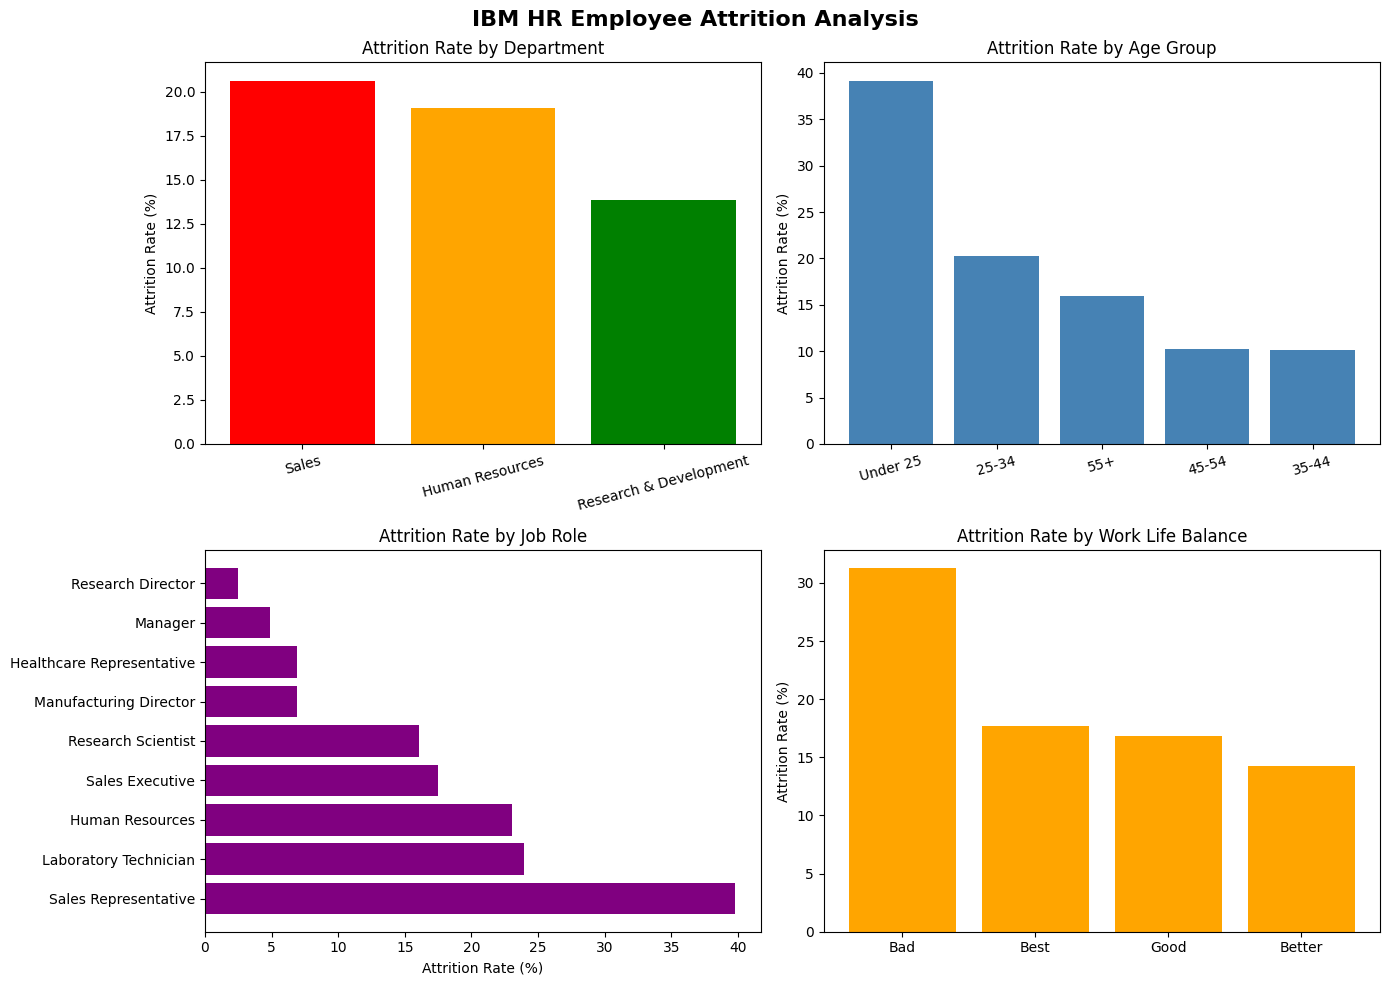

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IBM HR Employee Attrition Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Attrition by Department
axes[0,0].bar(result2['Department'], result2['Attrition_Rate'], color=['red','orange','green'])
axes[0,0].set_title('Attrition Rate by Department')
axes[0,0].set_ylabel('Attrition Rate (%)')
axes[0,0].tick_params(axis='x', rotation=15)

# Chart 2 — Attrition by Age Group
axes[0,1].bar(result3['Age_Group'], result3['Attrition_Rate'], color='steelblue')
axes[0,1].set_title('Attrition Rate by Age Group')
axes[0,1].set_ylabel('Attrition Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# Chart 3 — Attrition by Job Role
axes[1,0].barh(result4['JobRole'], result4['Attrition_Rate'], color='purple')
axes[1,0].set_title('Attrition Rate by Job Role')
axes[1,0].set_xlabel('Attrition Rate (%)')

# Chart 4 — Attrition by Work Life Balance
axes[1,1].bar(result5['Work_Life_Balance'], result5['Attrition_Rate'], color='orange')
axes[1,1].set_title('Attrition Rate by Work Life Balance')
axes[1,1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

## IBM HR Employee Attrition Analysis — Key Insights

1. Overall 16.12% of employees left the company 
   — 237 out of 1,470 employees

2. Sales department has the highest attrition 
   rate at 20.63% — needs immediate attention

3. Young employees under 25 leave the most 
   at 39.18% — company needs better retention 
   strategies for young talent

4. Sales Representatives have the highest 
   attrition by job role at 39.76%

5. Poor work life balance drives attrition — 
   employees with bad work life balance leave 
   at 31.25% compared to 14.22% for better balance

6. Research Directors are the most loyal employees 
   with only 2.50% attrition rate